In [1]:
from langchain_openai import ChatOpenAI
from langchain.tools import tool

In [2]:
llm = ChatOpenAI(
    model="gpt-5.4-mini"
)

Create an MCP client

In [3]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "chrome": {
            "transport":"stdio",
            "command":"npx",
            "args": [
                "-y",
                "chrome-devtools-mcp@latest",
            ],
        },
        "filesystem": {
            "transport": "stdio",
            "command": "npx",
            "args": [
                "-y",
                "@modelcontextprotocol/server-filesystem",
                "/Users/tousif/downloads"
            ],
        },
    }
)

In [4]:
tools = await client.get_tools()

In [5]:
from datetime import datetime
import asyncio
from langchain.tools import tool

@tool
def get_date_time() -> str:
    """Returns the current date and time."""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

@tool
async def wait(seconds: int) -> str:
    """Wait for the specified number of seconds before continuing."""
    await asyncio.sleep(seconds)
    return f"Waited {seconds} seconds."

In [6]:
all_tools = tools + [get_date_time, wait]

llm_with_tools = llm.bind_tools(all_tools)

In [7]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class ChatbotState(TypedDict):
    messages: Annotated[list, add_messages]

In [8]:
async def chatbot_node(state: ChatbotState):
    return {
        "messages": [
            await llm_with_tools.ainvoke(state["messages"])
        ]
    }

llm.bind_tools(tools) = gives the LLM the menu
ToolNode(tools)      = the kitchen that cooks the order

In [9]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver


tool_node = ToolNode(all_tools)

Let LangGraph automatically decide whether the chatbot should call tools or finish.

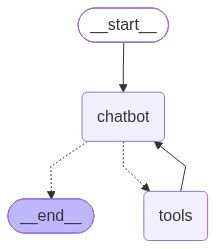

In [10]:
graph = StateGraph(ChatbotState)

graph.add_node("chatbot", chatbot_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chatbot")

graph.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph.add_edge("tools", "chatbot")
memory = InMemorySaver()

app = graph.compile(checkpointer=memory)

app

In [11]:
config = {
    "configurable": {
        "thread_id": "user-123"
    }
}

In [12]:
while True:
    user_input = input("You: ")

    if user_input.lower() in ["exit", "quit"]:
        break

    result = await app.ainvoke({
        "messages": [
            ("user",user_input)
        ]
    }, config=config,
    )

    for message in result["messages"]:
        if getattr(message, "tool_calls", None):
            for tool_call in message.tool_calls:
                print("Tool call", tool_call["name"], tool_call.get("args", {}))

    print("Bot", result["messages"][-1].content)

Bot Hi! How can I help?
Bot Understood. I’ll use the browser tools to inspect pages, wait when needed, and keep going until the task is completed. What would you like me to do?
Tool call new_page {'url': 'https://forms.gle/xyCvpido5cvNzUjG9', 'timeout': 120000}
Tool call wait_for {'text': ['Name', 'Submit', 'Your response has been recorded'], 'timeout': 120000}
Tool call take_snapshot {'verbose': True}
Tool call select_page {'pageId': 2, 'bringToFront': True}
Tool call list_pages {'{': 'ignored'}
Tool call list_pages {}
Tool call new_page {'url': 'https://forms.gle/xyCvpido5cvNzUjG9', 'timeout': 120000, 'background': False}
Tool call take_snapshot {'verbose': True}
Tool call select_page {'pageId': 2, 'bringToFront': True}
Tool call list_pages {}
Tool call new_page {'url': 'https://docs.google.com/forms/d/e/1FAIpQLSfUnrl-08O0D9BeZkiWXxWZ1wfuvwteuc0hWJs-o7VyW-UDqg/viewform?usp=send_form', 'timeout': 120000}
Tool call take_snapshot {'verbose': True}
Tool call select_page {'pageId': 2, 'br

In [13]:
# from pathlib import Path
# import base64
# import json

# def find_tool(name: str):
#     for tool in all_tools:
#         if tool.name == name or tool.name.endswith(f"_{name}") or tool.name.endswith(f"__{name}"):
#             return tool
#     available = ", ".join(tool.name for tool in all_tools)
#     raise ValueError(f"Tool {name!r} was not found. Available tools: {available}")

# def iter_values(value):
#     if value is None:
#         return

#     yield value

#     if isinstance(value, str):
#         try:
#             parsed = json.loads(value)
#         except Exception:
#             return
#         yield from iter_values(parsed)
#         return

#     if isinstance(value, dict):
#         for item in value.values():
#             yield from iter_values(item)
#         return

#     if isinstance(value, (list, tuple)):
#         for item in value:
#             yield from iter_values(item)
#         return

#     for attr in ("content", "artifact", "data"):
#         if hasattr(value, attr):
#             yield from iter_values(getattr(value, attr))

# def extract_image_bytes(result):
#     for item in iter_values(result):
#         mime_type = None
#         data = None

#         if isinstance(item, dict):
#             mime_type = item.get("mimeType") or item.get("mime_type")
#             data = item.get("data")
#         else:
#             mime_type = getattr(item, "mimeType", None) or getattr(item, "mime_type", None)
#             data = getattr(item, "data", None)

#         if data and (not mime_type or str(mime_type).startswith("image/")):
#             if isinstance(data, str) and data.startswith("data:"):
#                 data = data.split(",", 1)[1]
#             if isinstance(data, str):
#                 return base64.b64decode(data)
#             if isinstance(data, bytes):
#                 return data

#     return None

# async def save_page_screenshot(
#     url: str,
#     output_path: str = "langgraph-agent-with-mcp/hotelmudra-screenshot.png",
#     seconds: int = 10,
#     full_page: bool = True,
# ):
#     new_page = find_tool("new_page")
#     take_screenshot = find_tool("take_screenshot")

#     await new_page.ainvoke({"url": url, "timeout": 0})
#     await asyncio.sleep(seconds)

#     # Do not pass filePath here. Chrome DevTools MCP will attach the image
#     # to the response, then Python saves it into this notebook workspace.
#     result = await take_screenshot.ainvoke({"fullPage": full_page})
#     image_bytes = extract_image_bytes(result)

#     if image_bytes is None:
#         print("No inline image data was returned. Raw take_screenshot result:")
#         print(result)
#         return result

#     path = Path(output_path).resolve()
#     path.parent.mkdir(parents=True, exist_ok=True)
#     path.write_bytes(image_bytes)
#     print(f"Saved screenshot to {path}")
#     return str(path)

# await save_page_screenshot("https://hotelmudra-frontend.vercel.app/")